# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [3]:
import pandas as pd
import sklearn

### Step 1. Load the data

In [4]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv"
df = pd.read_csv(url)
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
x = df["Hours_Studied"].values.reshape(-1,1)
y = df["Marks"].values.reshape(-1,1)

### Step 2.b print the type of each

In [6]:
print(type(x))  # e.g. <class 'numpy.ndarray'>
print(type(y))  # e.g. <class 'numpy.ndarray'>

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [ ]:
import numpy as np   
#its numiric 
# Check unique values
print("Unique values:", np.unique(y))
print("Number of unique values:", len(np.unique(y)))

Unique values: [20.19 22.3  22.37 22.78 23.59 23.85 25.69 25.71 26.6  26.79 28.18 28.66
 28.97 29.19 29.25 29.52 30.   30.48 31.86 32.09 32.5  32.69 33.17 33.18
 33.63 33.69 34.   34.3  34.65 34.97 36.45 36.48 38.37 38.54 39.02 39.19
 39.9  39.91 40.48 40.76 41.76 41.97 43.82 43.99 44.22 44.32 46.27 46.64
 47.37 47.47 47.5  47.51 47.69 47.81 48.44 48.59 49.19 49.49 50.49 51.58
 52.23 52.57 53.01 53.36 53.44 53.79 55.08 55.42 55.7  56.24 56.31 56.48
 56.87 57.31 57.58 57.92 59.18 59.36 59.99 60.24 60.47 61.15 61.73 62.72
 63.23 64.45 65.17 65.78 65.99 66.26 66.63 66.73 67.54 68.87 70.27 70.39
 71.44 73.2  73.26]
Number of unique values: 99


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:

print("Number of samples:", x.shape[0])
print("Number of columns (features):", x.shape[1])
print("Target columns:", y.shape[1])

Number of samples: 100
Number of columns (features): 1
Target columns: 1


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
import numpy as np
df = pd.DataFrame({"x": x.flatten(), "y": y.flatten()})
df.describe()

,x,y
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

3.9.2


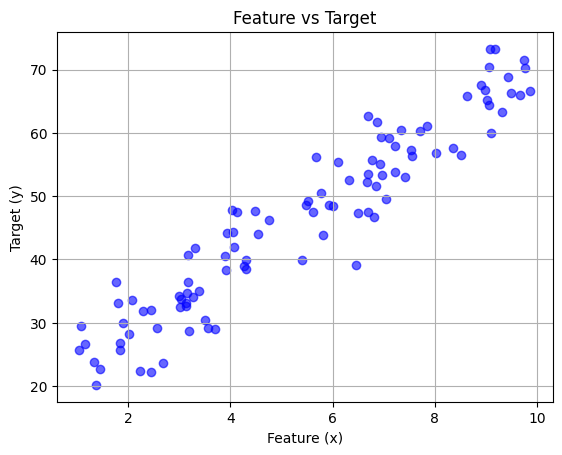

In [10]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.__version__)  # correct way to check version

# Now test the plot
plt.scatter(x, y, color='blue', alpha=0.6)
plt.xlabel("Feature (x)")
plt.ylabel("Target (y)")
plt.title("Feature vs Target")
plt.grid(True)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

The relationship between the feature and the target is INCREASING (positive linear).


### Step 7. Initialize a `LinearRegression` model

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (80, 1)
x_test shape: (20, 1)
y_train shape: (80, 1)
y_test shape: (20, 1)


### Step 9.a Train the model on the training set

In [13]:
model.fit(x_train, y_train)  # train the model  

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [14]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [[5.16443841]]
Intercept: [18.53857851]


### Step 9.c how much marks do we get per 1 hour of study?

In [17]:
print("Marks per 1 hour of study:",model.coef_)

Marks per 1 hour of study: [[5.16443841]]


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [16]:
marks_per_10min = model.coef_[0][0] * (10/60)
print("Marks added per 10 minutes:", marks_per_10min)

Marks added per 10 minutes: 0.8607397355832593


### Step 9.e if one doesn't study at all, how much marks do they get?

In [19]:
print("Marks with 0 hours of study:", model.intercept_[0])

Marks with 0 hours of study: 18.538578512317276


### Step 10. Evaluate the model on the test set

In [20]:
# Step 1: Make predictions on test set
y_pred = model.predict(x_test)

# Step 2: Evaluate with R² score
print("R² Score:", model.score(x_test, y_test))

# Optional: also check Mean Squared Error
from sklearn.metrics import mean_squared_error
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.9258085525213727
MSE: 14.731128407667583


R² Score: 0.926

The model explains 92.6% of the variance in marks
Means the model is a very good fit
Scale is 0 to 1 → closer to 1 = better


"Hours studied explains 92.6% of the variation in marks"



### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [21]:
# Take 3 samples from test set
samples = x_test[:3]
true_labels = y_test[:3]
predictions = model.predict(samples)

# Compare
for i in range(3):
    print(f"Sample {i+1}: Predicted={predictions[i][0]:.2f}, Actual={true_labels[i][0]:.2f}")

Sample 1: Predicted=34.14, Actual=32.50
Sample 2: Predicted=64.50, Actual=67.54
Sample 3: Predicted=53.55, Actual=55.70


### Step 12. Plot the data and the regression line

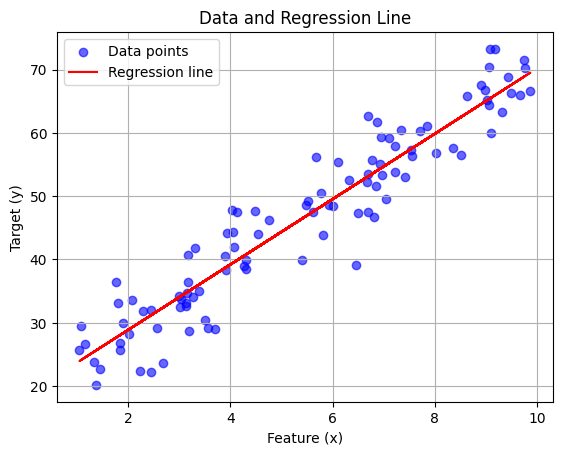

In [22]:
plt.scatter(x, y, color='blue', alpha=0.6, label='Data points')
plt.plot(x, model.predict(x), color='red', label='Regression line')
plt.xlabel("Feature (x)")
plt.ylabel("Target (y)")
plt.title("Data and Regression Line")
plt.legend()
plt.grid(True)
plt.show()